# 4. Where OWL-D fails, and why

Needs no GPU. Reads the saved detections and about 60 patch images; runs no model.

Every point gets a label. An annotated animal is **found**, or missed at the
**edge** (within 16 px of the patch border), **touching** another animal (within
12 px), or in **clear view**. A detection is a **hit**, or a false alarm on
**empty ground**, at the **edge** (tested first, before proximity), a **double
hit** on an animal already found, **placement off** (near an animal it failed
to match), or **away from animals**.

These labels say where errors happen. The zoomed crops in section 8 are how you
check whether they are errors at all.

**What inspection found** (twelve errors of each kind, spread over as many
mosaics as the kind allows; only false alarms on empty ground, 16 in all from
eight mosaics, fall short of twelve):

- **Edge false alarms** were real caribou cut by the tile border in about 11 of
  12. The border band is 12% of each patch's area but holds 53% of all errors.
- **False alarms away from animals** were real caribou missing from the
  annotations in about 8 of 12.
- **False alarms on empty ground** were mostly genuine mistakes: dark mud on
  snow, pale patches on bare mud, a post, the edge of the imagery.
- **Misses in clear view** had no single cause: fully visible adults missed,
  two close animals covered by one detection, and a few points placed at the
  wrong end of the body. An early guess that they were mainly calves did not
  hold up across mosaics.

So every model's measured precision is a lower bound, and the penalty grows
with how many animals a model finds. **Nothing here changes the headline
metrics**, which score against the ground truth as given.


In [1]:
# --- 0. Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# --- 1. Configuration ---
ASSETS  = "/content/drive/MyDrive/OWL_Caribou_Project"
RESULTS = "/content/drive/MyDrive/owl_caribou_overhead/results"

RUN_NAME = "full_cah"
MODEL    = "owl-d"                      # the model whose failures are drawn
COMPARE  = ["owl-d", "caribou-owl-c", "owl-c", "owl-t"]   # for the tiling cost
RADIUS   = 20.0
PATCHES_PER_GALLERY = 8
CROPS_PER_KIND      = 12
N_BOOT, SEED        = 5000, 0

from pathlib import Path
if not (Path(ASSETS) / "data" / "test" / "gt.csv").is_file():
    raise RuntimeError(f"{ASSETS}/data/test/gt.csv not found. Put the assets there as the README's "
                       "'Expected assets' section describes, or point ASSETS at where they are.")


In [ ]:
# === CODE SYNC (auto-generated by `python -m owlcaribou.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m owlcaribou.sync   and reopen this notebook.")

In [4]:
# --- 3. Start the session (no GPU needed) ---
from owlcaribou.session import start_session

session = start_session(assets=ASSETS, results=RESULTS,
                        require_gpu=False, verify_assets=False)

session: Colab | device cuda (NVIDIA A100-SXM4-40GB, 39.49 GB)
  torch   2.11.0+cu128 | CUDA 12.8 | Python 3.13.15
  assets  /content/drive/MyDrive/OWL_Caribou_Project
  results /content/drive/MyDrive/owl_caribou_overhead/results
  code    c26c4d3f466e


In [5]:
# --- 4. Label every point, and count the errors by kind ---
from owlcaribou import failures as F, io as oio, metrics
from owlcaribou.data import load_ground_truth, verify_mosaic_rule

run = session.paths.run_dir(RUN_NAME)
out = run / "failures"
images = session.paths.test_data

truth = load_ground_truth(session.paths.ground_truth)
patch_names = [row["images"] for row in oio.read_csv(run / MODEL / "per_image.csv")]
assert len(patch_names) == 2607, f"expected 2607 evaluated patches, found {len(patch_names)}"
verify_mosaic_rule(patch_names, truth)

# Every model must be complete and come from one run of one code version.
run_code = oio.require_one_run(run, COMPARE)
print(f"detections: one run of all {len(COMPARE)} models, code {run_code}")
print()
predictions = {m: metrics.load_predictions(run / m / "detections.csv") for m in COMPARE}
outcomes = F.analyse(predictions[MODEL], truth, patch_names, RADIUS)

# The labels must account for exactly the errors the headline metrics count.
reference = metrics.evaluate(predictions[MODEL], truth, patch_names, RADIUS)
labelled = (sum(o.tp for o in outcomes), sum(o.fp for o in outcomes), sum(o.fn for o in outcomes))
assert labelled == (reference.tp, reference.fp, reference.fn), (labelled, reference)

counts = F.breakdown(outcomes)
rows = []
for group, plural, kinds in (("false alarm", "false alarms", counts["false_alarms"]),
                             ("miss", "missed animals", counts["misses"])):
    total = sum(kinds.values())
    print(f"{plural}: {total}")
    for kind, n in sorted(kinds.items(), key=lambda item: -item[1]):
        print(f"  {n:5d}  {n / total:6.1%}  {kind}")
        rows.append({"model": MODEL, "error": group, "kind": kind, "count": n, "share": n / total})
    print()
_ = oio.write_csv(out / f"{MODEL}_error_kinds.csv", rows)

detections: one run of all 4 models, code c26c4d3f466e

false alarms: 490
    332   67.8%  edge
     83   16.9%  away from animals
     49   10.0%  double hit
     16    3.3%  empty ground
     10    2.0%  placement off

missed animals: 452
    263   58.2%  clear view
    166   36.7%  edge
     23    5.1%  touching



In [6]:
# --- 5. Under which conditions do errors concentrate? ---
print("by herd density (annotated animals in the patch)")
density = F.by_group(outcomes, F.density, F.DENSITY_ORDER)
for r in density:
    if r["animals"]:
        print(f"  {r['group']:>6s}  patches {r['patches']:5d}  animals {r['animals']:6d}  "
              f"P {r['precision']:.3f}  R {r['recall']:.3f}  F1 {r['f1_score']:.3f}")
oio.write_csv(out / f"{MODEL}_by_density.csv", density)

print("\nby ground sample distance")
resolution = F.by_group(outcomes, F.resolution)
for r in resolution:
    print(f"  {r['group']:>6s}  patches {r['patches']:5d}  animals {r['animals']:6d}  "
          f"P {r['precision']:.3f}  R {r['recall']:.3f}  F1 {r['f1_score']:.3f}")
oio.write_csv(out / f"{MODEL}_by_resolution.csv", resolution)
print("  (resolution follows the flight plan, so it is confounded with location and herd)")

print("\nconcentration at the patch border")
edges = F.edge_concentration(outcomes)
for r in edges:
    print(f"  {r['margin_px']:3.0f} px band holds {r['animals_in_band']:5.1%} of animals but "
          f"{r['misses_in_band']:5.1%} of misses; {r['detections_in_band']:5.1%} of detections but "
          f"{r['false_alarms_in_band']:5.1%} of false alarms")
_ = oio.write_csv(out / f"{MODEL}_edge_concentration.csv", edges)

from owlcaribou.data import PATCH_SIZE
band = next(r for r in edges if r["margin_px"] == F.EDGE_MARGIN)
errors_in_band = band["false_alarms_in_band"] * reference.fp + band["misses_in_band"] * reference.fn
band_area = 1 - ((PATCH_SIZE - 2 * F.EDGE_MARGIN) / PATCH_SIZE) ** 2
print(f"  the {F.EDGE_MARGIN:.0f} px band is {band_area:.0%} of each patch's area but holds "
      f"{errors_in_band / (reference.fp + reference.fn):.0%} of all errors")

by herd density (annotated animals in the patch)
       1  patches   453  animals    453  P 0.875  R 0.940  F1 0.906
     2-5  patches   731  animals   2258  P 0.947  R 0.956  F1 0.952
    6-20  patches   552  animals   6000  P 0.969  R 0.963  F1 0.966
     21+  patches   116  animals   3745  P 0.972  R 0.972  F1 0.972

by ground sample distance
   50 mm  patches  1576  animals   7155  P 0.963  R 0.954  F1 0.959
   90 mm  patches  1031  animals   5301  P 0.958  R 0.976  F1 0.967
  (resolution follows the flight plan, so it is confounded with location and herd)

concentration at the patch border
    8 px band holds  5.7% of animals but 30.1% of misses;  6.9% of detections but 60.4% of false alarms
   16 px band holds 11.4% of animals but 36.7% of misses; 12.4% of detections but 68.6% of false alarms
   32 px band holds 22.6% of animals but 45.1% of misses; 23.7% of detections but 71.0% of false alarms
  the 16 px band is 12% of each patch's area but holds 53% of all errors


In [7]:
# --- 6. What does tiling cost each model? ---
from owlcaribou import uncertainty as U
from owlcaribou.data import mosaic_from_patch_name

print(f"Interior scores keep the whole-patch matching and leave the {F.EDGE_MARGIN:.0f} px border band")
print("out of the counting only: recall is the share of animals outside the band that were found")
print("(by any detection), precision the share of detections outside the band that hit an animal")
print("(anywhere), F1 their harmonic mean. The gap to the full-patch numbers is what the band")
print("contributes: an estimate of the tiling cost, likely generous, since every band error is")
print("left out whether tiling caused it or not.\n")
tiling = []
for model in COMPARE:
    full  = metrics.evaluate(predictions[model], truth, patch_names, RADIUS)
    inner = F.interior_scores(predictions[model], truth, patch_names, RADIUS)
    tiling.append({"model": model, "f1_full": full.f1_score, "f1_interior": inner["f1_score"],
                   "precision_full": full.precision, "precision_interior": inner["precision"],
                   "recall_full": full.recall, "recall_interior": inner["recall"],
                   "interior_animals": inner["animals"], "interior_animals_found": inner["tp"],
                   "interior_detections": inner["detections"], "interior_detections_hit": inner["hits"],
                   "straddling_pairs": inner["straddling_pairs"]})
    print(f"  {model:14s} F1 {full.f1_score:.3f} -> {inner['f1_score']:.3f}   "
          f"precision {full.precision:.3f} -> {inner['precision']:.3f}   "
          f"recall {full.recall:.3f} -> {inner['recall']:.3f}")
    print(f"  {'':14s} {inner['tp']} of {inner['animals']} interior animals found, "
          f"{inner['hits']} of {inner['detections']} interior detections hit an animal, "
          f"{inner['straddling_pairs']} matched pairs straddle the band line")
_ = oio.write_csv(out / "tiling_cost.csv", tiling)

# Does the headline comparison survive once the band is left out of the count?
PAIR = ("owl-d", "caribou-owl-c")
groups = [mosaic_from_patch_name(n) for n in patch_names]
whole = U.cluster_bootstrap({m: U.patch_statistics(predictions[m], truth, patch_names, RADIUS)
                             for m in PAIR}, groups, n_boot=N_BOOT, seed=SEED)
inner = U.cluster_bootstrap({m: F.interior_statistics(predictions[m], truth, patch_names, RADIUS)
                             for m in PAIR}, groups, n_boot=N_BOOT, seed=SEED)
print(f"\ninterior only, {PAIR[0]} minus {PAIR[1]}, 95% mosaic bootstrap "
      "(count bias over interior counts)")
paired = []
for metric in ("f1_score", "precision", "recall", "aggregate_count_bias_percent"):
    d = inner.difference(*PAIR, metric)
    paired.append(d)
    print(f"  {metric:30s} {d['estimate']:+.4f}  [{d['ci_low']:+.4f}, {d['ci_high']:+.4f}]  "
          f"owl-d better in {d['share_a_better']:6.1%}")
_ = oio.write_csv(out / "interior_paired.csv", paired)

full = whole.difference(*PAIR, "f1_score")
f1 = next(d for d in paired if d["metric"] == "f1_score")
if f1["ci_low"] > 0:
    verdict = f"excludes zero: {PAIR[0]}'s F1 lead survives without the band"
elif f1["ci_high"] < 0:
    verdict = f"excludes zero on the other side: without the band {PAIR[1]} has the higher F1"
else:
    verdict = "includes zero: the F1 lead is not shown to survive once the band is left out of the count"
print(f"\nOn the full patches the F1 difference is {full['estimate']:+.4f} "
      f"[{full['ci_low']:+.4f}, {full['ci_high']:+.4f}], {PAIR[0]} ahead in {full['share_a_better']:.1%} "
      f"of replicates. The interior F1 difference {f1['estimate']:+.4f} "
      f"[{f1['ci_low']:+.4f}, {f1['ci_high']:+.4f}] {verdict}.")


Interior scores keep the whole-patch matching and leave the 16 px border band
out of the counting only: recall is the share of animals outside the band that were found
(by any detection), precision the share of detections outside the band that hit an animal
(anywhere), F1 their harmonic mean. The gap to the full-patch numbers is what the band
contributes: an estimate of the tiling cost, likely generous, since every band error is
left out whether tiling caused it or not.

  owl-d          F1 0.962 -> 0.980   precision 0.961 -> 0.986   recall 0.964 -> 0.974
                 10752 of 11038 interior animals found, 10789 of 10943 interior detections hit an animal, 291 matched pairs straddle the band line
  caribou-owl-c  F1 0.946 -> 0.976   precision 0.906 -> 0.960   recall 0.990 -> 0.992
                 10945 of 11038 interior animals found, 10938 of 11388 interior detections hit an animal, 291 matched pairs straddle the band line
  owl-c          F1 0.857 -> 0.883   precision 0.846 -> 0.

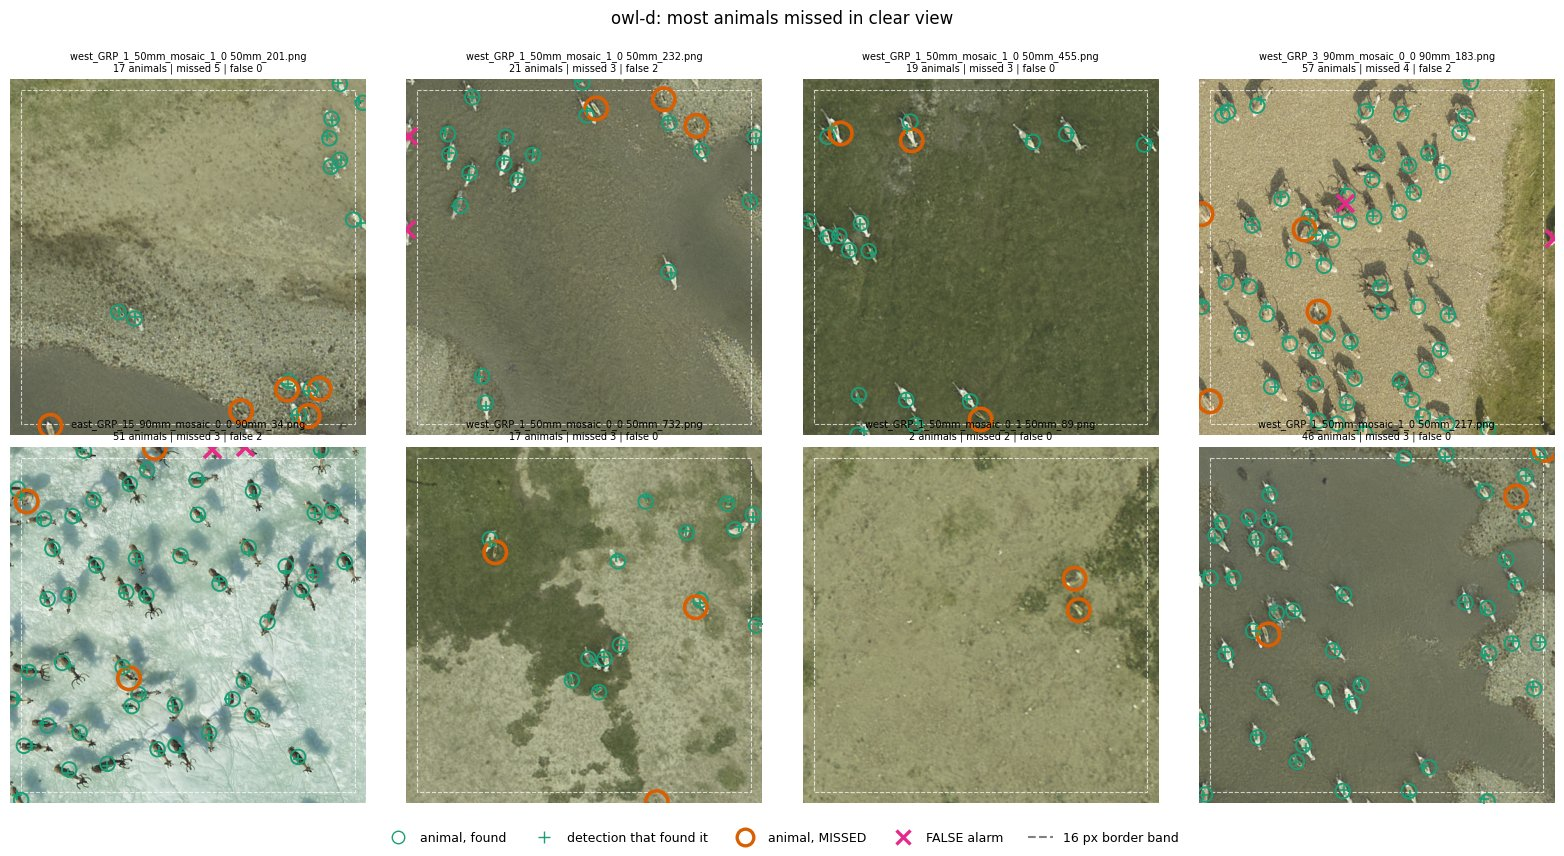

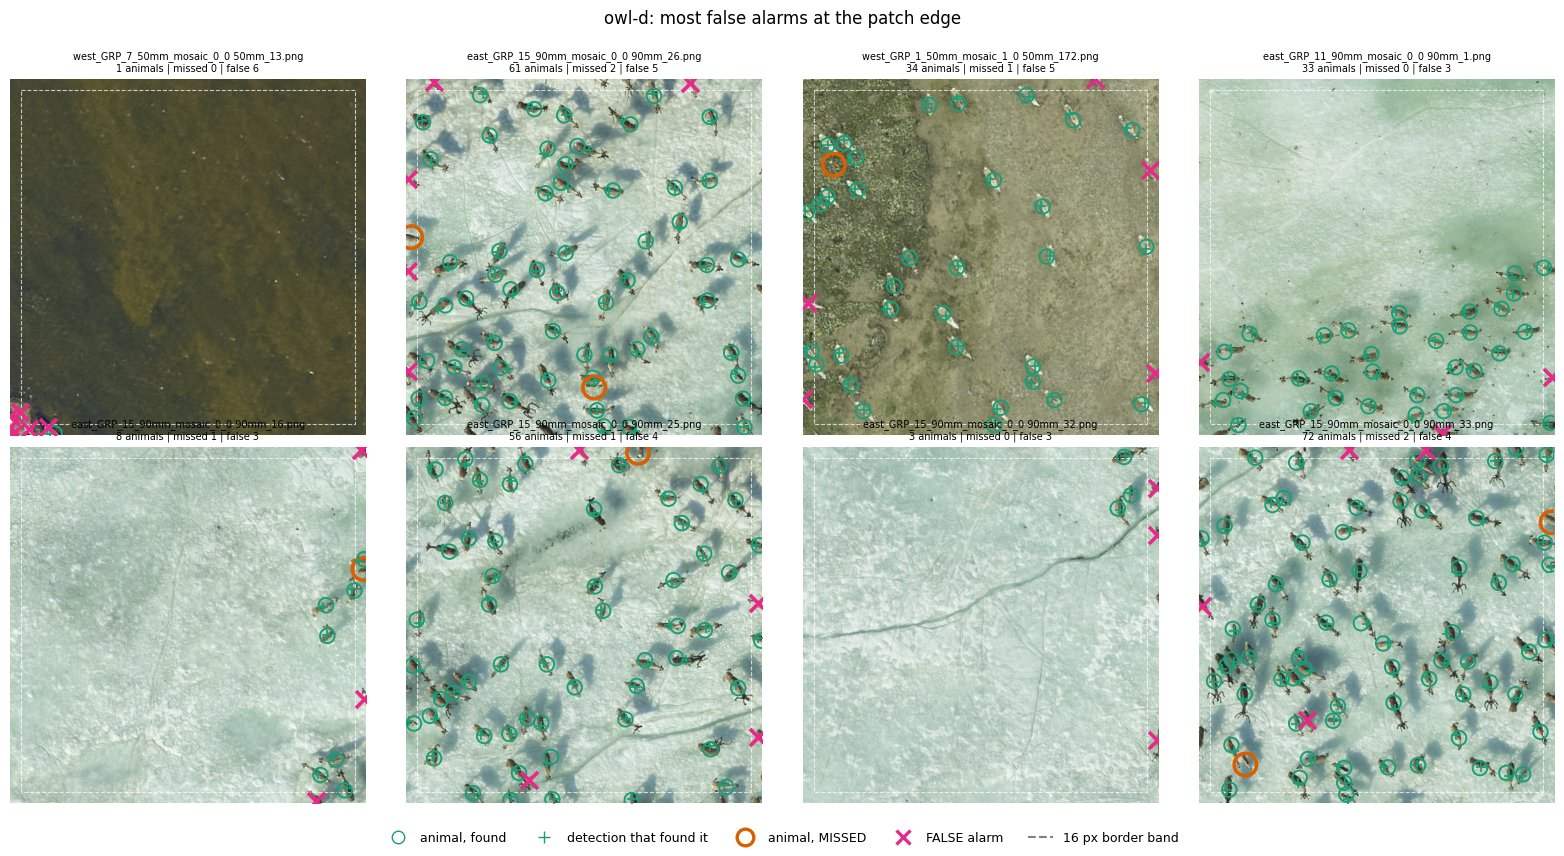

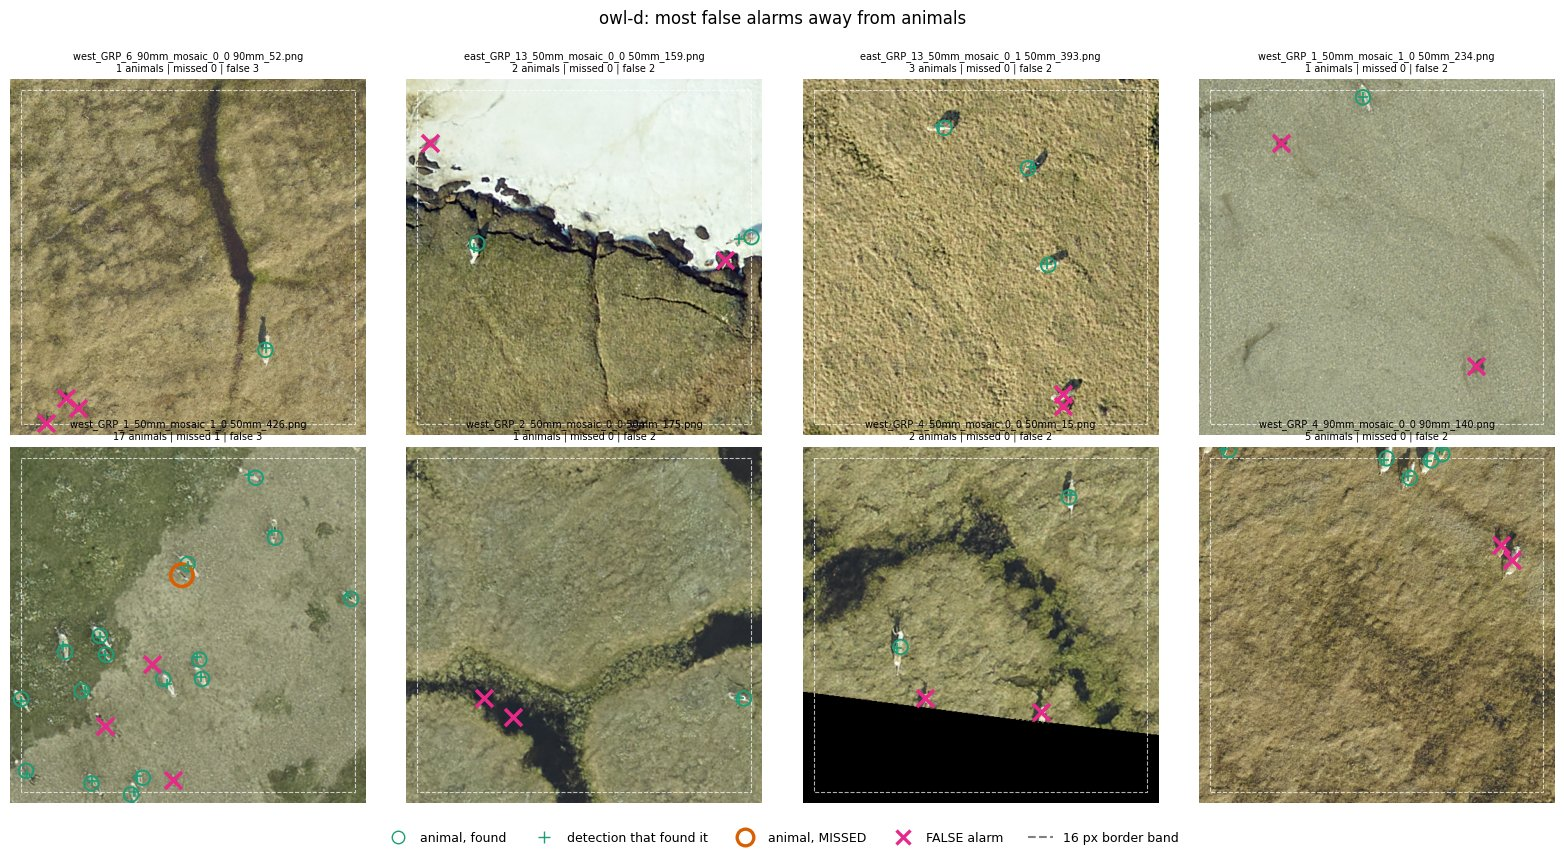

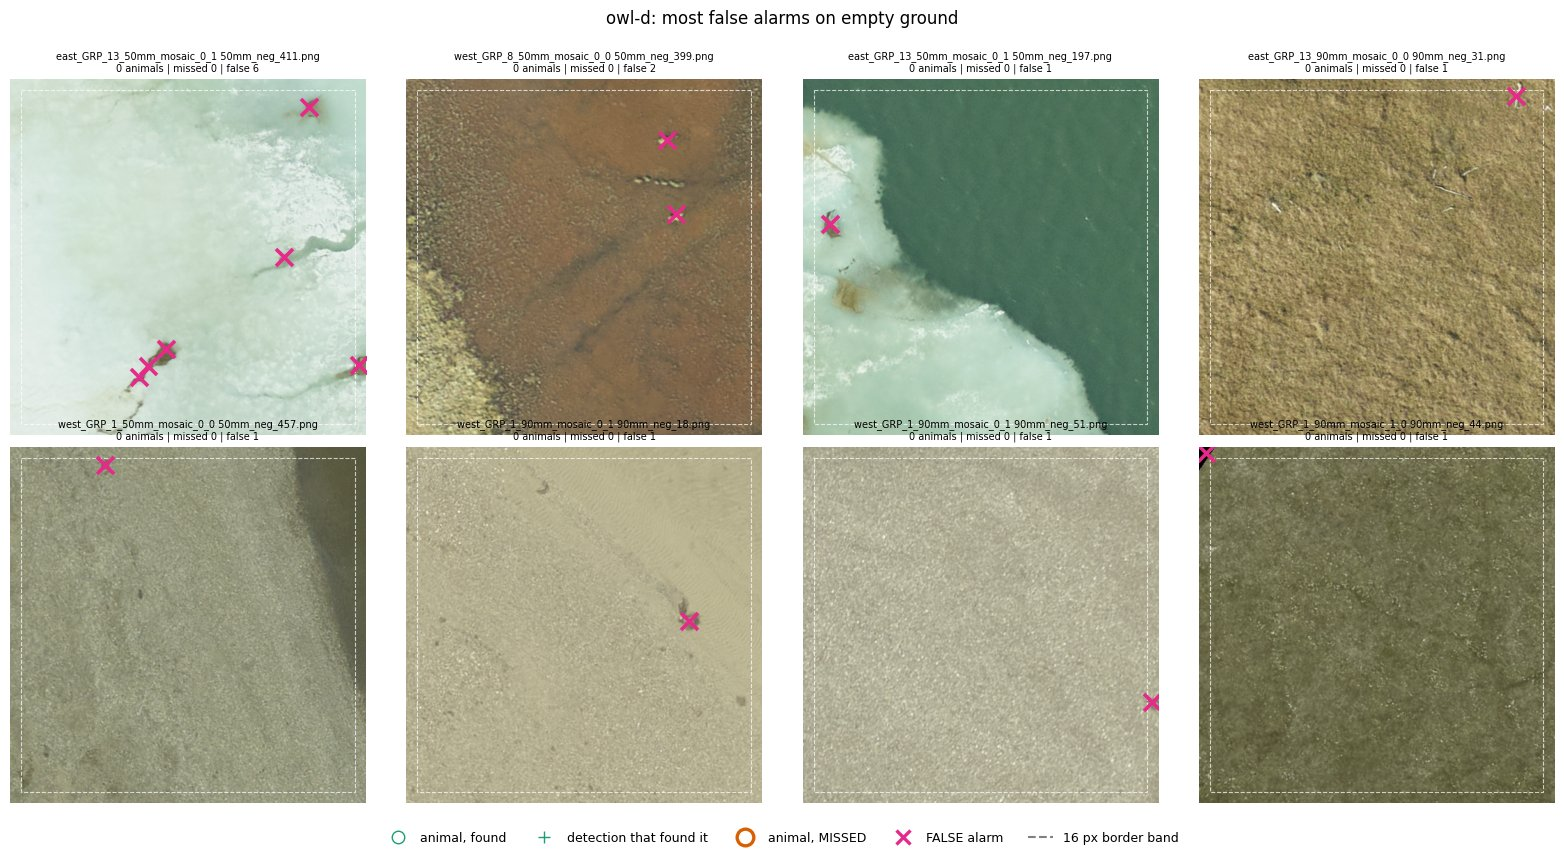

In [8]:
# --- 7. Whole patches, worst first ---
import matplotlib.pyplot as plt

views = [
    ("most animals missed in clear view", lambda o: o.misses("clear view")),
    ("most false alarms at the patch edge", lambda o: o.false_alarms("edge")),
    ("most false alarms away from animals", lambda o: o.false_alarms("away from animals")),
    ("most false alarms on empty ground", lambda o: o.false_alarms("empty ground")),
]
for title, count in views:
    chosen = F.worst(outcomes, count, PATCHES_PER_GALLERY)
    slug = title.replace(" ", "_")
    F.gallery(chosen, images, f"{MODEL}: {title}", out / f"gallery_{slug}.png")
    plt.show()

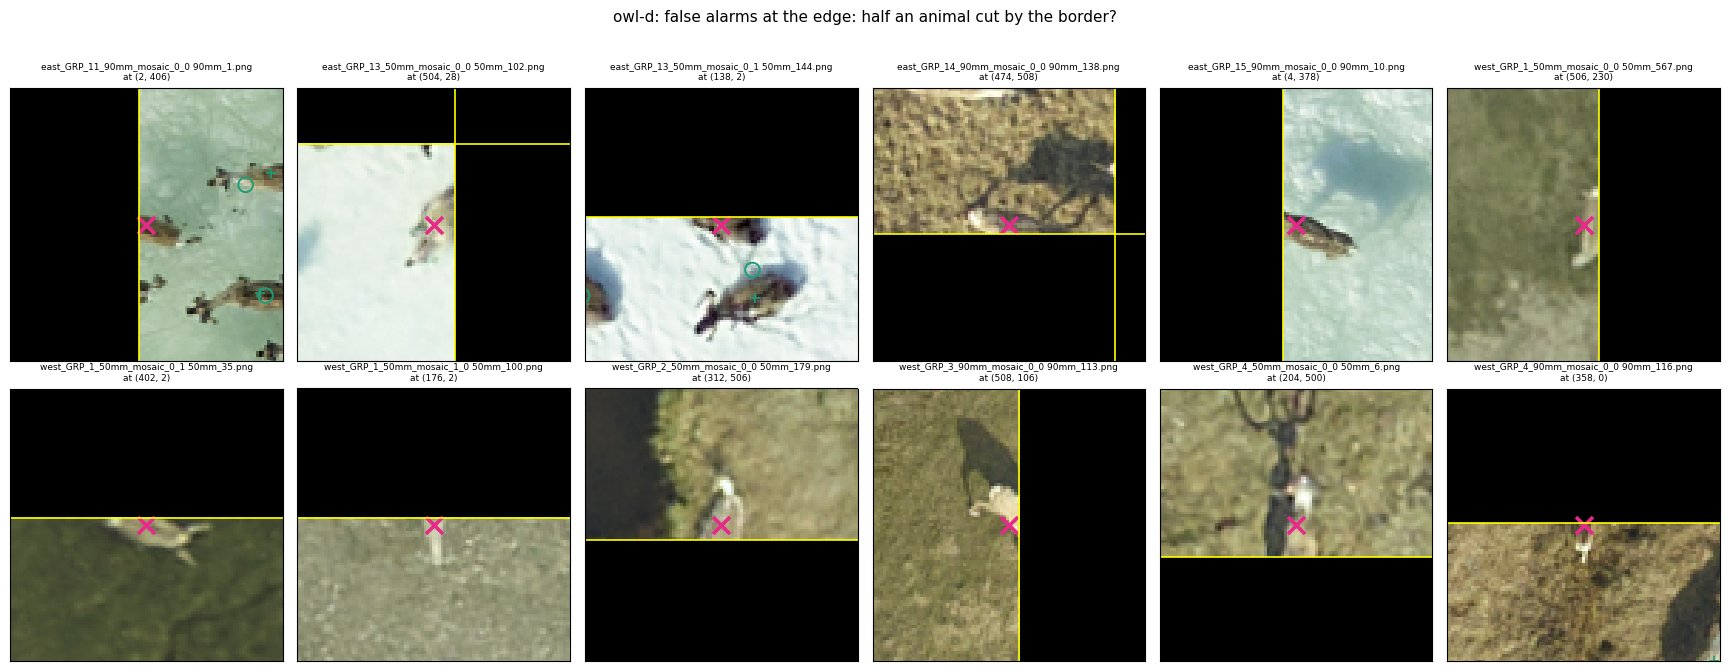

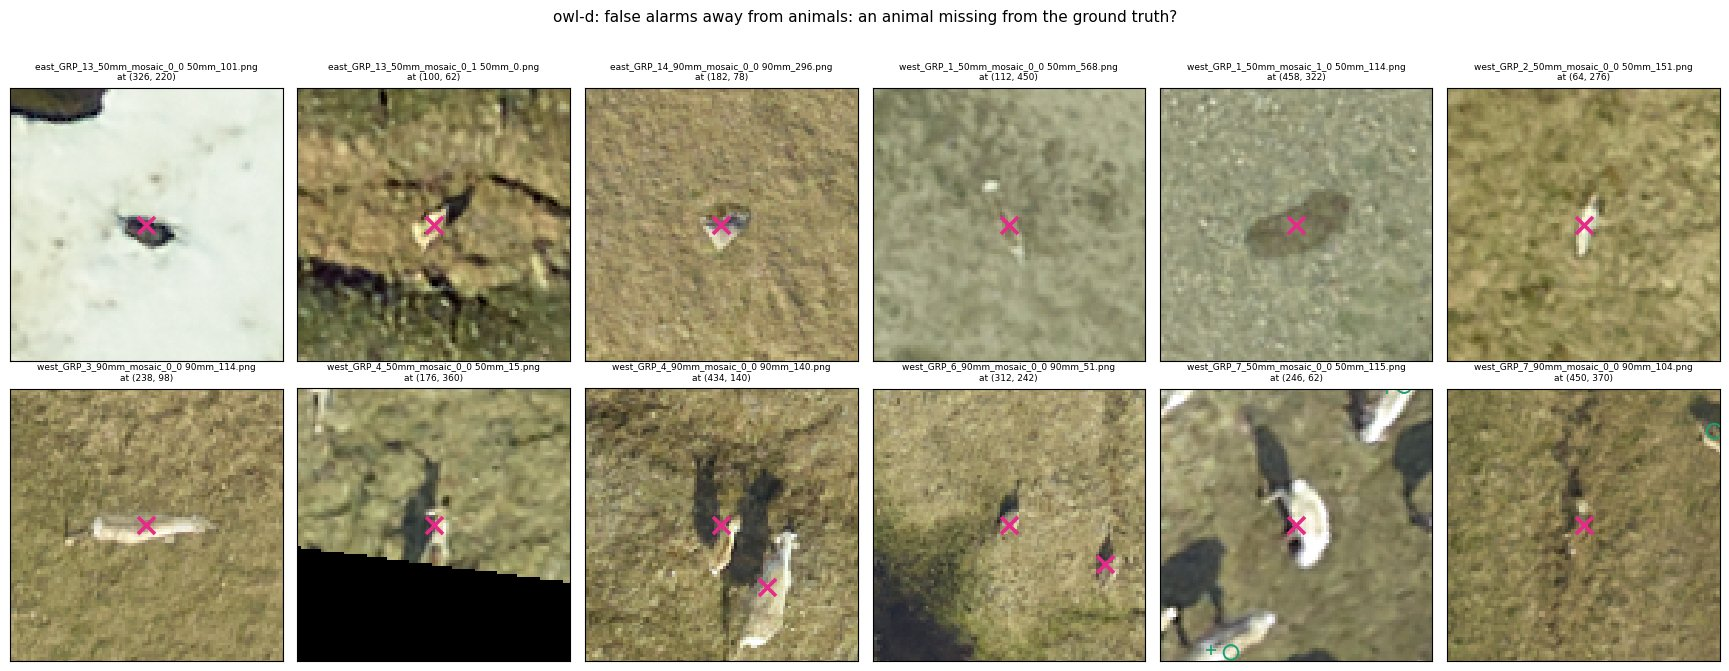

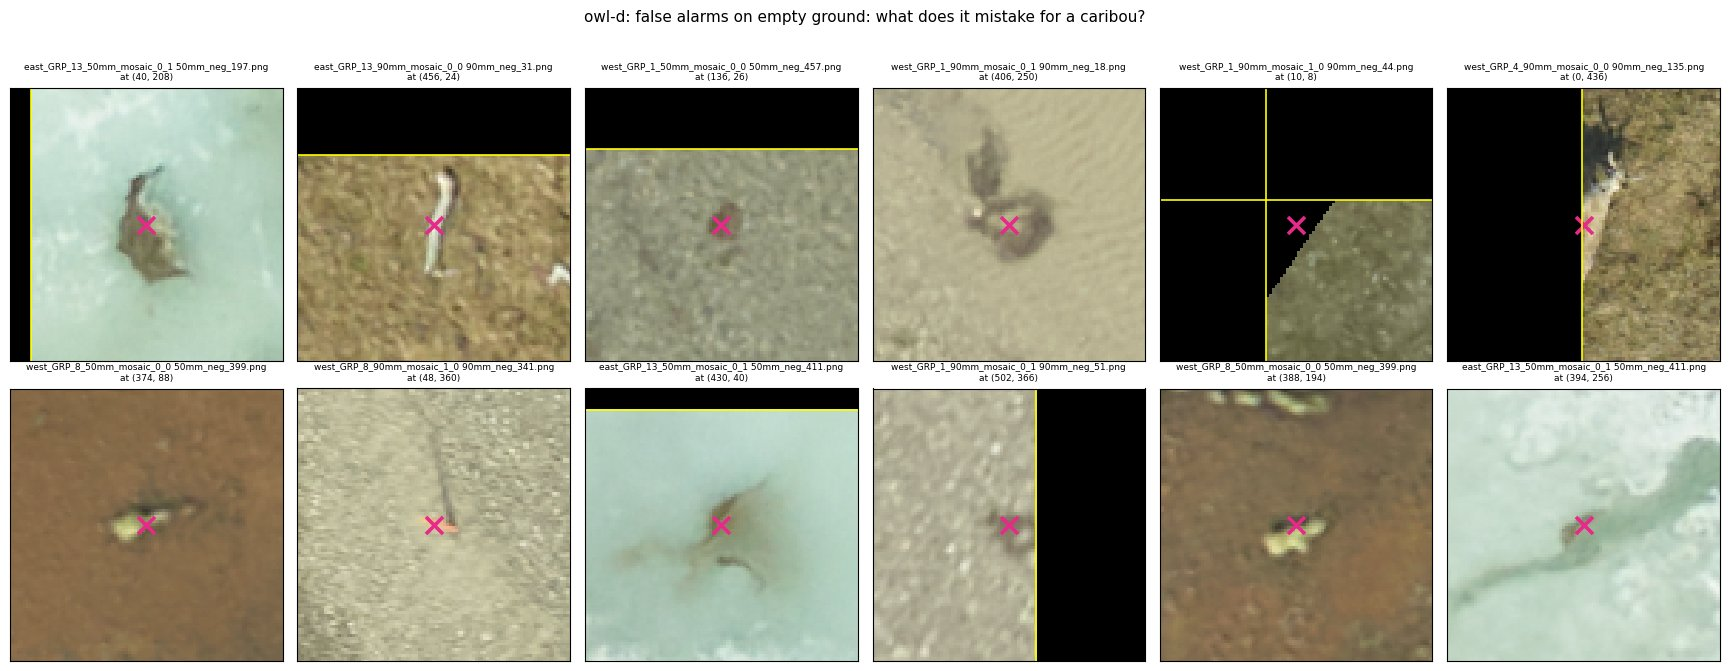

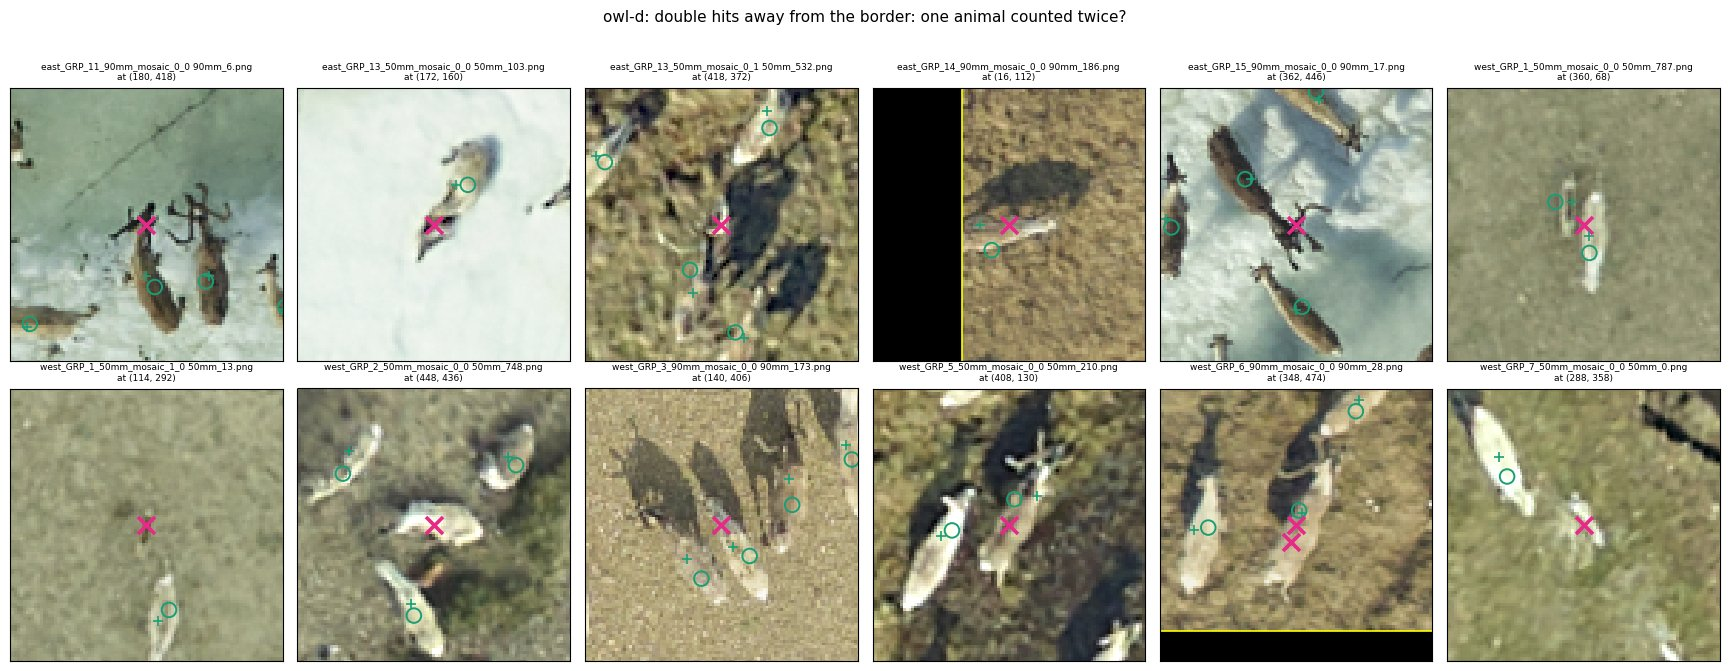

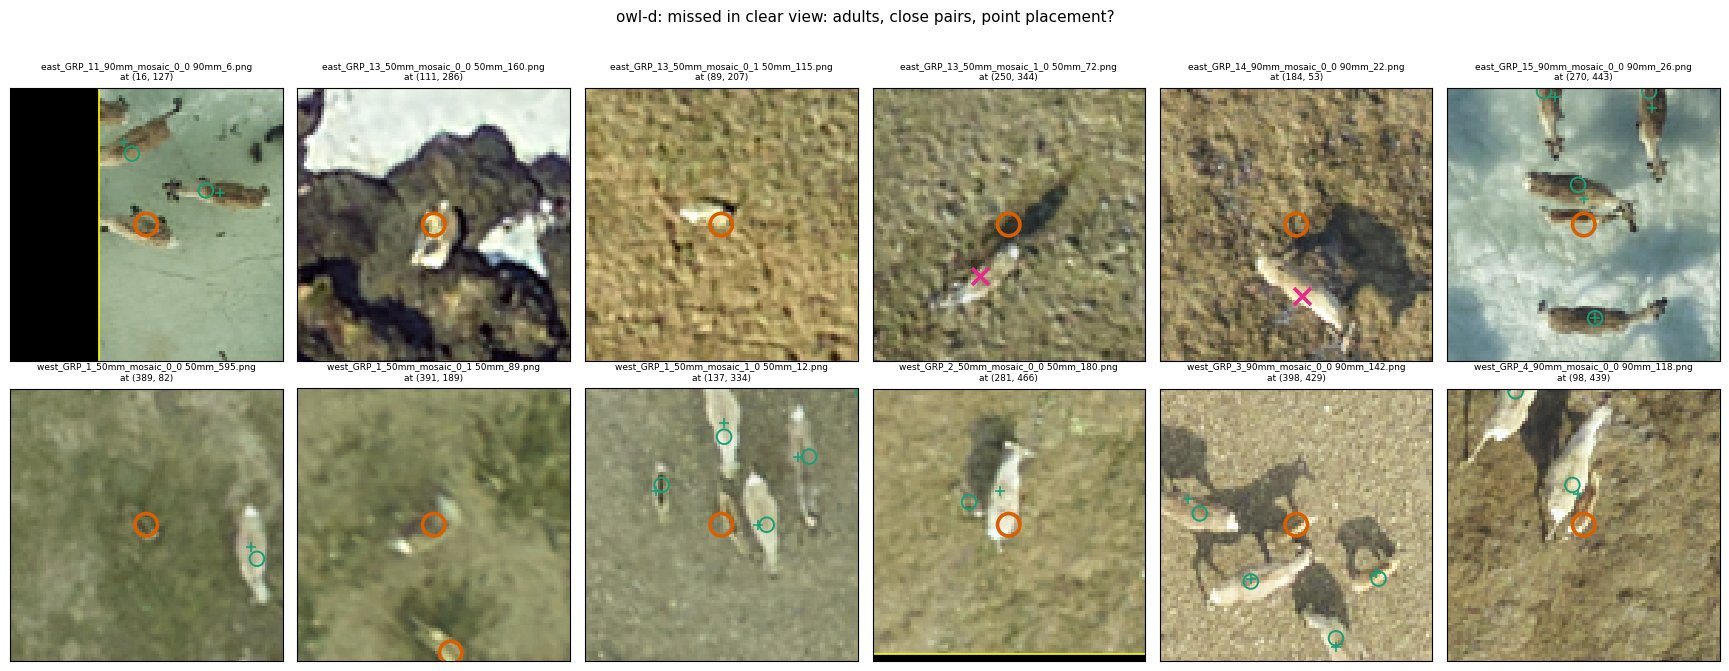

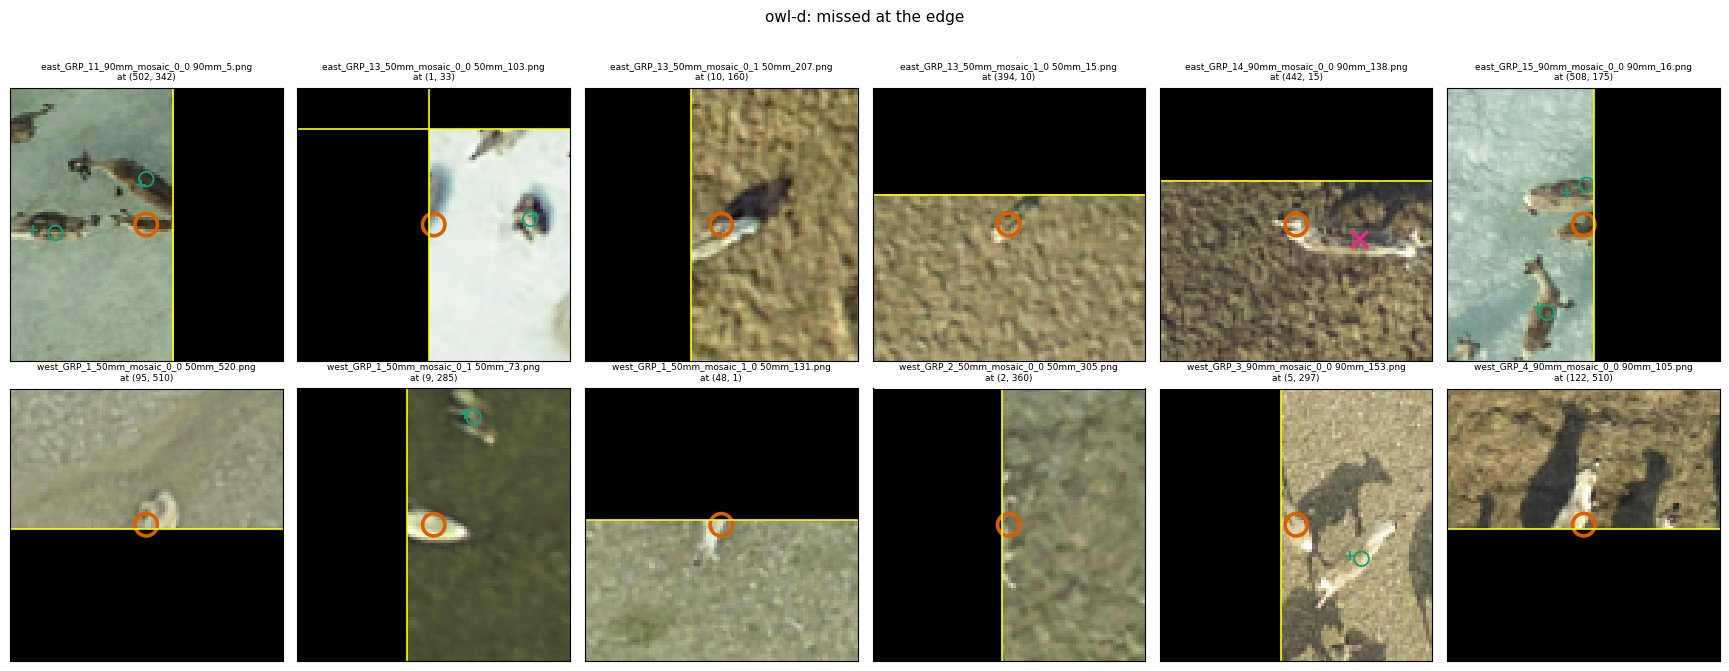

written to /content/drive/MyDrive/owl_caribou_overhead/results/full_cah/failures


In [9]:
# --- 8. Zoomed in, one error per panel ---
import matplotlib.pyplot as plt

zooms = [
    ("edge", "false_alarm", "false alarms at the edge: half an animal cut by the border?"),
    ("away from animals", "false_alarm", "false alarms away from animals: an animal missing from the ground truth?"),
    ("empty ground", "false_alarm", "false alarms on empty ground: what does it mistake for a caribou?"),
    ("double hit", "false_alarm", "double hits away from the border: one animal counted twice?"),
    ("clear view", "miss", "missed in clear view: adults, close pairs, point placement?"),
    ("edge", "miss", "missed at the edge"),
]
for kind, of, title in zooms:
    picks = F.error_points(outcomes, kind, of, CROPS_PER_KIND)
    slug = f"{of}_{kind}".replace(" ", "_")
    F.crops(picks, images, f"{MODEL}: {title}", out / f"crops_{slug}.png")
    plt.show()

session.record(out, model=MODEL, radius=RADIUS, edge_margin=F.EDGE_MARGIN,
               near=F.NEAR, touching=F.TOUCHING)
print("written to", out)

## What to look for in the crops

**Edge false alarms.** A body running into the yellow border line is a real
animal cut by the tile. Most crops look like that, so most edge false alarms
are an artefact of scoring pre-cut patches; a survey run on whole mosaics with
overlapping tiles would largely not make them.

**False alarms away from animals.** A caribou shape under the pink cross with
no green or orange circle is an animal the ground truth does not list. Each is
a point of precision the model is being denied.

**False alarms on empty ground.** These are the model's genuine confusions:
dark blobs on snow and pale patches on mud read as caribou.

**Misses in clear view.** Look for fully visible animals with nothing near,
pairs of animals with a single detection between them, and a detection sitting
at the far end of a long body - the last counts as one miss plus one false
alarm for a single animal.

## Limits

- The kinds are geometric rules with fixed distances (16, 12 and 40 px). A
  different threshold moves some errors between kinds.
- "Real animal" is a judgement made by eye on twelve crops per kind. It shows a
  problem exists and roughly how common it is, not its exact size.
- Measuring the ground-truth gap properly would need the tile layout inside
  each mosaic, which the dataset does not record.
- The gap between full-patch and interior scores in section 6 is an estimate of
  the tiling cost, likely generous: every error in the band is left out whether
  tiling caused it or not, and a band detection that matched an interior animal
  may itself be a cut animal from the neighbouring tile.

**Next:** `05_sweep_gpu.ipynb` (GPU).
